# Singular Value Decomposition (SVD): Image Compression

Singular Value Decomposition (SVD) is a fundamental matrix factorization in linear algebra. It decomposes any real m×n matrix A into three distinct components:

SVD Formula:
$$A = U \Sigma V^T$$
Where:
*   **$U$**: An $m \times m$ orthogonal matrix (left singular vectors representing spatial patterns).
*   **$\Sigma$**: An $m \times n$ diagonal matrix containing singular values $\sigma_i$ in descending order.
*   **$V^T$**: The transpose of an $n \times n$ orthogonal matrix (right singular vectors representing feature variations).

### The Geometry of SVD
SVD can be interpreted as a three-step geometric transformation:
1.  **Rotation ($V^T$)**: Rotating the input space to align with the principal directions.
2.  **Scaling ($\Sigma$)**: Stretching or shrinking along these new axes based on the magnitude of singular values.
3.  **Rotation ($U$)**: Rotating the result into the output space.

In image processing, the singular values $\sigma_i$ tell us the "energy" or importance of specific patterns. By keeping only the largest singular values, we can achieve **Low-Rank Approximation**, significantly reducing storage while maintaining visual clarity.


Implemetation:

Now, I will load a high-resolution image, convert it to grayscale (to treat it as a single 2D matrix), and apply SVD at various ranks k.

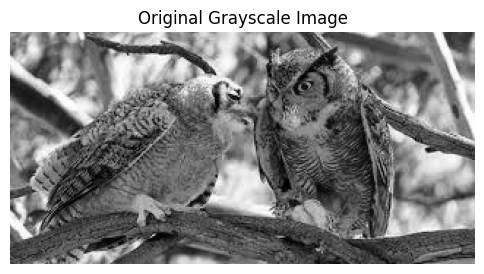

Matrix A shape: (159, 318)
Singular values found: 159


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os

# 1. Load and Preprocess
# Replace 'bird.jpg' with your actual image path
img = imread('bird.jpg')

# Convert to grayscale to create a 2D matrix A
if img.ndim == 3:
    A = np.mean(img, axis=2)
else:
    A = img

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# 2. Compute SVD
U, S, VT = np.linalg.svd(A, full_matrices=False)

# Check dimensions
print(f"Matrix A shape: {A.shape}")
print(f"Singular values found: {len(S)}")

### Visualization: Low-Rank Reconstruction
We reconstruct the image using the top $k$ singular triplets.
Mathematically, the approximation $A_k$ is:
$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$


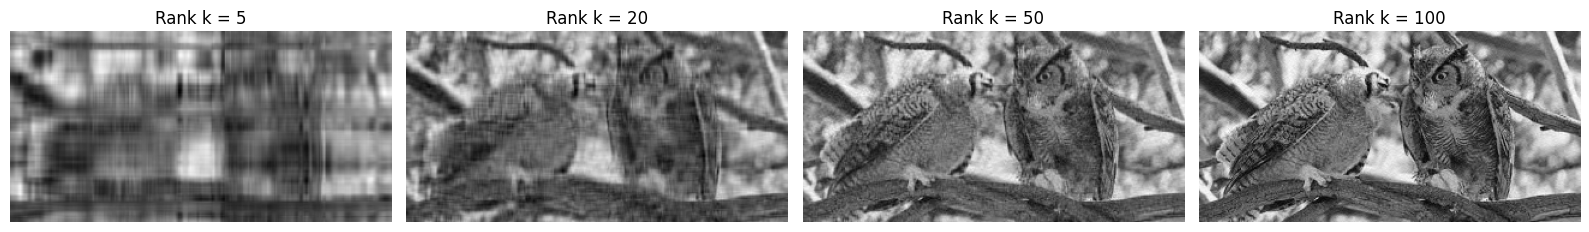

In [2]:
ranks = [5, 20, 50, 100]

plt.figure(figsize=(16, 4))
for i, k in enumerate(ranks):
    # Reconstruct using rank k
    A_approx = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

    plt.subplot(1, 4, i+1)
    plt.imshow(A_approx, cmap='gray')
    plt.title(f"Rank k = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

To evaluate the quality of our compression, we use two primary metrics:

Frobenius Norm Error: The "distance" between the original and compressed image.

$\text{Error } k = ||A - A_k||_F$

Cumulative Energy: The percentage of total variance captured by k components


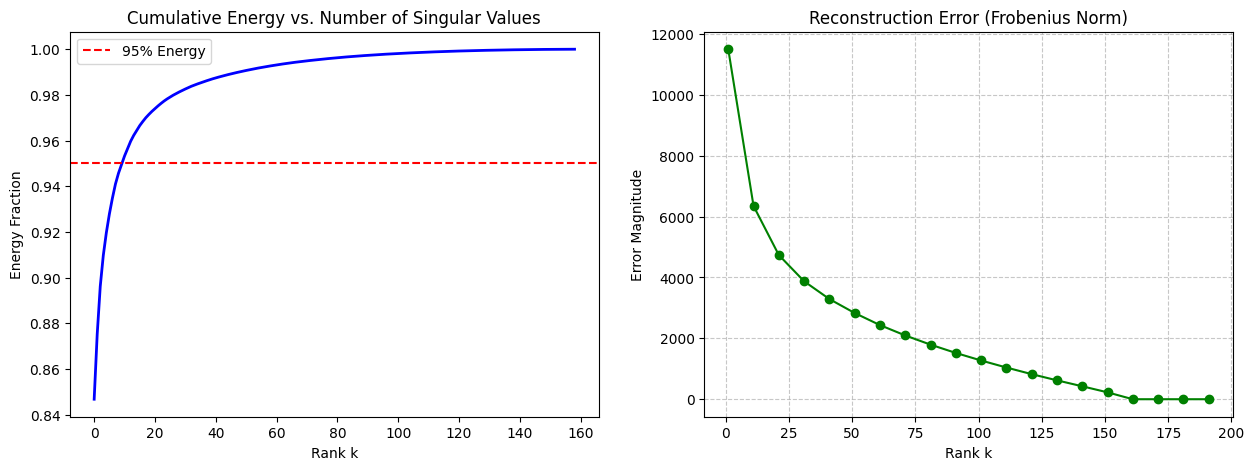

In [4]:
# 1. Energy Analysis
total_energy = np.sum(S**2)
cumulative_energy = np.cumsum(S**2) / total_energy

# 2. Error Analysis (Frobenius Norm)
errors = []
test_ranks = np.arange(1, 200, 10)
for k in test_ranks:
    A_k = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    error = np.linalg.norm(A - A_k, 'fro')
    errors.append(error)

# Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Energy Plot
ax1.plot(cumulative_energy, color='blue', lw=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% Energy')
ax1.set_title("Cumulative Energy vs. Number of Singular Values")
ax1.set_xlabel("Rank k")
ax1.set_ylabel("Energy Fraction")
ax1.legend()

# Error Plot
ax2.plot(test_ranks, errors, marker='o', color='green')
ax2.set_title("Reconstruction Error (Frobenius Norm)")
ax2.set_xlabel("Rank k")
ax2.set_ylabel("Error Magnitude")
ax2.grid(True, linestyle='--', alpha=0.7) # Adds a clean, dashed grid
plt.show()